# LMECA2300: Advanced Numerical Methods
## Assignment 3

**Students:**
- Student 1: Victor Lepère (61502000)
- Student 2: Max Opdecam(77062000)

Let us consider the shape $\Gamma$ as a collection of $N$ segments $\Gamma_i$. We will denote their midpoint by $\mathbf m_i$. At the middle of each segment, we would like to impose the total pressure to be zero, i.e. 
\begin{align*}
0 = P_0 e^{-j k \hat{\mathbf{u}} \cdot \mathbf{m}_j}  + \frac{\omega \rho_0}{4} \int_\Gamma H_0^{(2)} (k||\mathbf m_j - \mathbf r' ||_2) \, v_n(\mathbf r') \, d\Gamma' \qquad j = 1, \dotsc, N
\end{align*}
Where  $\hat{\mathbf{u}}$ is the unit direction of the incident field of pressure. We now decompose the unknowns velocities as linear combination of piecewise unit-constant basis functions whose support restricts to a single segment as follows
$$
v_n = \sum_{i=1}^N x_i v_{n,i} \quad \text{ with } v_{n,i} = \begin{cases}
1 \text{ on } \Gamma_i \\
0 \text{ otherwise}
\end{cases} 
$$
Substituing back into the previous expression, we get:
\begin{align*}
0 = P_0 e^{-j k \hat{\mathbf{u}} \cdot \mathbf{m}_j}  + \frac{\omega \rho_0}{4} &\int_\Gamma H_0^{(2)} (k||\mathbf m_j - \mathbf r' ||_2) \, \sum_{i=1}^N x_i v_{n,i} \, d\Gamma' \qquad &j = 1, \dotsc, N \\
\sum_{i=1}^N x_i &\int_\Gamma H_0^{(2)} (k||\mathbf m_j - \mathbf r' ||_2) \, v_{n,i} \, d\Gamma' = -\frac{4 P_0}{\omega \rho_0} e^{-j k \hat{\mathbf{u}} \cdot \mathbf{m}_j} \qquad &j = 1, \dotsc, N \\
\sum_{i=1}^N x_i & \underbrace{\int_{\Gamma_i} H_0^{(2)} (k||\mathbf m_j - \mathbf r' ||_2) \, d\Gamma'}_{A_{j i}} = \underbrace{-\frac{4 P_0}{\omega \rho_0} e^{-j k \hat{\mathbf{u}} \cdot \mathbf{m}_j}}_{b_j} \qquad &j = 1, \dotsc, N
\end{align*}
Hence we end up with a linear system $A x = b$. Solving it yields the distribution of normal velocities over the segments. Based on this distribution, we can compute the total pressure everywhere using techniques of the previous assignments. We first define some physical constants and implement the segment abstraction as follows:

In [49]:
### Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation
from scipy.special import hankel2
from math import ceil

### Physical constants
rho0 = 1.2 # air, 20°C, 1 atm
f = 1/16 # [hz]
w = 2*np.pi*f # air -> 343 = w/k
k = w/343
lambda_ = (2*np.pi)/k

### A segment
class Edge:
    def __init__(self,r1,r2):
        self.r1 = np.asarray(r1)
        self.r2 = np.asarray(r2)

    def __integrate_hankel(self, a, b, m, case):
        """
        Aux. function that integrates Hankel function from a to b via singularity extraction

        @param a: lower intergration bound
        @param b: upper integration bound
        @param case: symmetric/general case
        @param m: number of integration points
        """
        s = np.linspace(a, b, m)
        if case == 1:
            diff = s[:, np.newaxis] * (self.r2 - self.obs)
        else:
            diff = self.obs - (self.r1 + s[:, np.newaxis] * (self.r2 - self.r1))
        rho = np.linalg.norm(diff, axis=1)
        singularity_mask = k*rho <= lambda_/1000

        evals = np.zeros_like(rho, dtype=np.complex128)
        cst = 1 - 1j*(2/np.pi)*(np.euler_gamma - np.log(2))
        evals[singularity_mask] = cst
        subset_rho = rho[~singularity_mask]
        evals[~singularity_mask] = hankel2(0, k*subset_rho) + 1j*(2/np.pi)*np.log(k*subset_rho)

        h = (b - a) / m

        evals[0] *= 1/2
        evals[-1] *= 1/2
        first_term = h*np.sum(evals)
        if case == 1:
            if a == 0:
                last = 0
            else:
                last = a*(np.log(a)-1)
            second_term = -1j*(2/np.pi)*((b-a)*(np.log(k)+np.log(np.linalg.norm(self.r2-self.obs))) + (b*(np.log(b)-1) - last))
        else:
            pass

        return first_term + second_term
    
    def integrate_sym(self, Vn, obs):
        """
        Integrates complex amplitude for an obsever point ON the segment, and thus takes advantage of symmetry.

        @param Vn: constant normal velocity
        @param obs: coord. of observer
        """
        self.obs = obs
        L1 = np.linalg.norm(obs - self.r1)
        L2 = np.linalg.norm(obs - self.r2)

        sbar = np.fmin(L1, L2) / np.fmax(L1, L2)

        m = 40
        if L1 == 0:
            return (Vn*w*rho0*L2/4)*self.__integrate_hankel(0, 1, m, 1)
        elif L1 < L2:
            return (Vn*w*rho0/4)*((L2+L2)*self.__integrate_hankel(0, sbar, m, 1) + (L2)*self.__integrate_hankel(sbar, 1, m, 1))
        else:
            return (Vn*w*rho0*L1/2)*self.__integrate_hankel(0, 1, m, 1)
        
    def integrate_gen(self, Vn, obs,m=100):
        """
        Integrates for general observer point off the segment. Can be vectorized.

        @param Vn: constant normal velocity
        @param obs: coord. of observer (or vector of coords)
        @param m: number of integration points
        """
        obs = np.atleast_2d(obs) # (N,2)

        s = np.linspace(0, 1, m) # (m,)
        diff = obs[:, np.newaxis, :] - (self.r1 + s[:, np.newaxis] * (self.r2-self.r1)) # (N,m,2)
        rho = np.linalg.norm(diff, axis=-1) # (N,m)

        H = hankel2(0, k * rho) # (N,m)
        if np.any(np.isnan(H)):
            raise ValueError("Hankel function evaluated at singular point, change geometry or grid.")
        H[:, 0] *= 1/2
        H[:, -1] *= 1/2
        integral = w * rho0 * Vn * np.linalg.norm(self.r2 - self.r1) * np.sum(H, axis=1)/4 / m # (N,)
        return integral

Then we define a geometry:

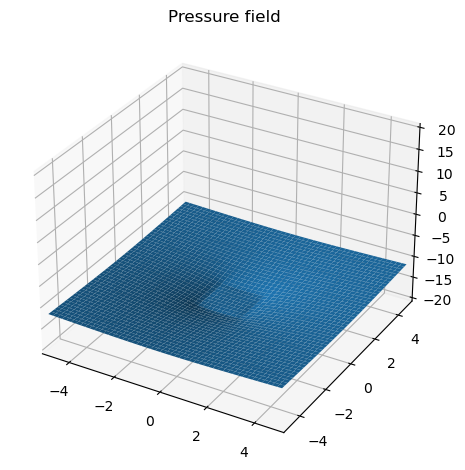

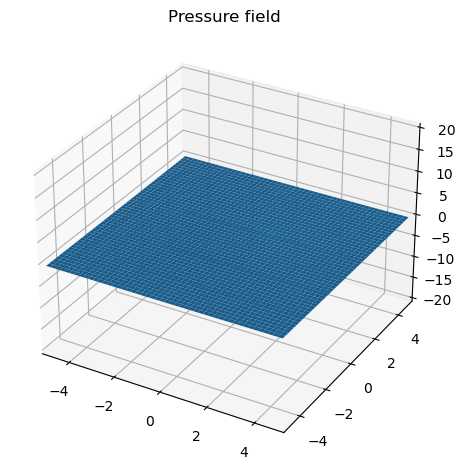

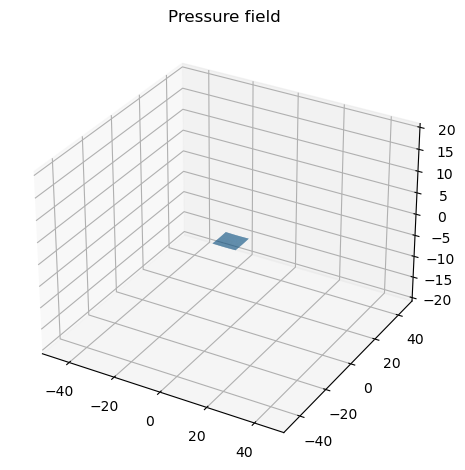

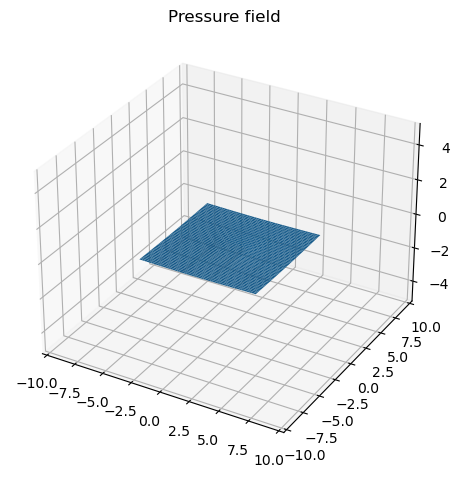

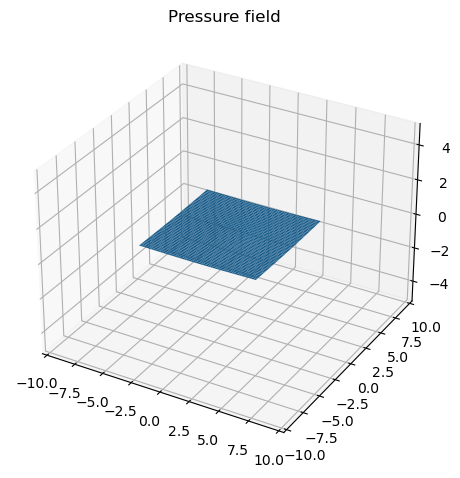

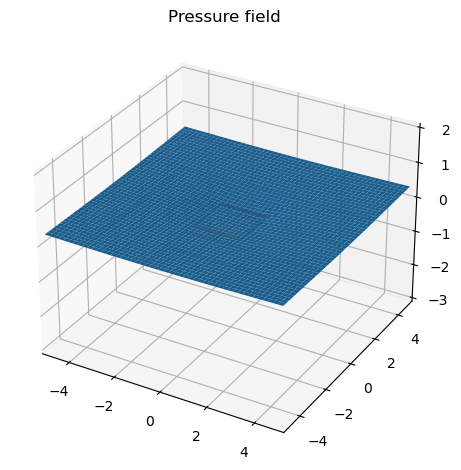

In [50]:
### the shape (to change)
# for now, it is simply a square
shape = [Edge([-1, -1], [1, -1]),
         Edge([1, -1], [1, 1]),
         Edge([1, 1], [-1, 1]),
         Edge([-1, 1], [-1, -1])]

# show geometry
for s in shape:
    plt.plot([s.r1[0], s.r2[0]], [s.r1[1], s.r2[1]])
plt.show()

And build the linear system !

In [51]:
def build_system(shape, p_inc):
    """
    build linear system Ax = b as described above

    @param shape: a collection of Edge's
    @param p_inc: function that yields the complex amplitude of the incident field
    """

    N = len(shape)
    A = np.zeros((N, N), dtype=complex)
    b = np.zeros(N, dtype=complex)

    for j in range(N):
        for i in range(N):
            edge = shape[j]
            midpoint = 0.5 * (edge.r1 + edge.r2)
            if i == j:
                A[i,j] = edge.integrate_sym(1, midpoint)
            else:
                A[i,j] = edge.integrate_gen(1, midpoint, 100)[0]
        b[j] = -p_inc(midpoint)

    return A,b 

### build system          
P0 = 1
u = [np.sqrt(2)/2, np.sqrt(2)/2]
p_inc = lambda r : P0 * np.exp(1j * k * r @ np.asarray(u))
A,b = build_system(shape, p_inc)

### solve system
x = np.linalg.solve(A,b)

Now that we know the velocity distribution over the shape, we can compute the pressure field everywhere. Let us consider an uniform grid with nodes defined inside and outside the shape. We get:

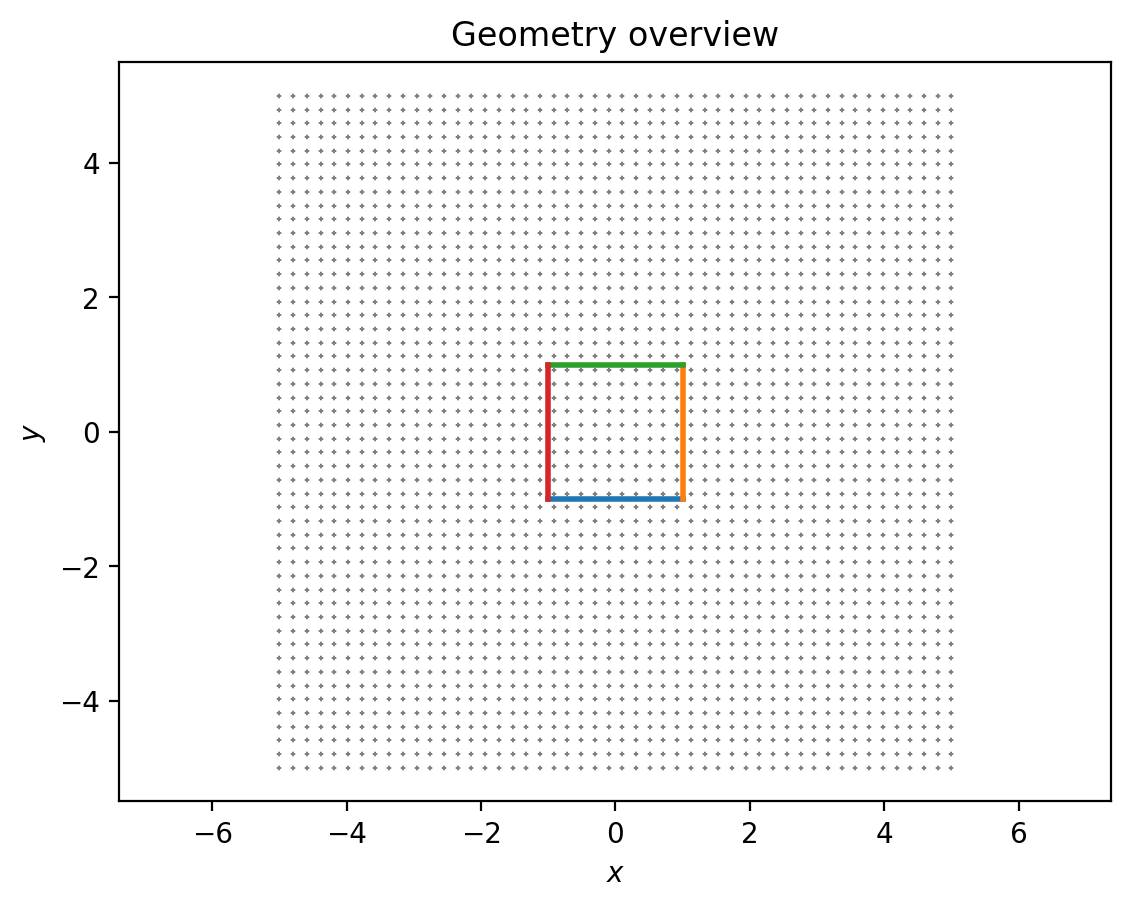

In [52]:
### Create grid
gridsize = 50
x = np.linspace(-5, 5, gridsize)
X, Y = np.meshgrid(x, x)
coord_array = np.column_stack((X.ravel(), Y.ravel()))

### Plot
plt.figure(dpi=200)
for i in range(len(shape)):
    plt.plot([shape[i].r1[0], shape[i].r2[0]], [shape[i].r1[1], shape[i].r2[1]], "-", linewidth=2)
    plt.scatter(coord_array[:, 0], coord_array[:, 1], c='gray', marker="+", s=.75)

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.axis('equal')
plt.title("Geometry overview")
plt.show()

In [54]:
grid_radiated = np.zeros((gridsize * gridsize, len(shape)), dtype=complex)
for i in range(len(shape)):
    grid_radiated[:,i] = shape[i].integrate_gen(x[i], coord_array)
grid_radiated = np.sum(grid_radiated, axis=-1) # sum up all contributions

grid_incident = p_inc(coord_array)

grid_total = grid_incident + grid_radiated

plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

def animate(t):
    plt.cla()
    pressures = np.real(grid_total * np.exp(1j* t/2))
    ax.plot_surface(X, Y, pressures.reshape(X.shape))

    range = 50
    plt.xlim(-range, range)
    plt.ylim(-range, range)
    ax.set_zlim(-range//2, range//2)
    ax.set_title("Pressure field")
    fig.tight_layout()
    

matplotlib.animation.FuncAnimation(fig, animate, frames=50, interval=60)